# ============================================================
# NOTEBOOK 05
# PERSONALIZED FEDERATED LEARNING
# ============================================================

"""
Objective

Implement Personalized Federated Learning
using a Per-FedAvg inspired strategy.

Pipeline

1. Load CIFAR-10
2. Load Non-IID partitions
3. Train local client models
4. Aggregate with FedAvg
5. Personalize each client's model
6. Evaluate global performance
7. Save results
"""

print("="*60)
print("NOTEBOOK 05")
print("PERSONALIZED FEDERATED LEARNING")
print("="*60)

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import copy
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader
from torch.utils.data import Subset

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*60)
print("Device :", device)
print("="*60)

Device : cuda


In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2023,0.1994,0.2010)
    )

])

trainset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("="*60)
print("Training Samples :", len(trainset))
print("Testing Samples  :", len(testset))
print("="*60)

100%|██████████| 170M/170M [58:21<00:00, 48.7kB/s]


Training Samples : 50000
Testing Samples  : 10000


In [4]:
# ============================================================
# LOAD NON-IID PARTITIONS
# ============================================================

PARTITION_DIR = "saved_partitions"

os.makedirs(PARTITION_DIR, exist_ok=True)

NONIID_FILE = os.path.join(
    PARTITION_DIR,
    "noniid_clients.pkl"
)

NUM_CLIENTS = 10
ALPHA = 0.3

if os.path.exists(NONIID_FILE):

    print("Loading saved Non-IID partitions...")

    with open(NONIID_FILE,"rb") as f:

        noniid_clients = pickle.load(f)

else:

    print("Generating Non-IID partitions...")

    def dirichlet_partition(targets,
                            num_clients,
                            alpha):

        targets=np.array(targets)

        client_indices=[[] for _ in range(num_clients)]

        for cls in np.unique(targets):

            cls_idx=np.where(targets==cls)[0]

            np.random.shuffle(cls_idx)

            proportions=np.random.dirichlet(
                np.repeat(alpha,num_clients)
            )

            split=np.split(
                cls_idx,
                (np.cumsum(proportions)*len(cls_idx)).astype(int)[:-1]
            )

            for i,idx in enumerate(split):

                client_indices[i].extend(idx)

        return client_indices

    noniid_clients = dirichlet_partition(
        trainset.targets,
        NUM_CLIENTS,
        ALPHA
    )

    with open(NONIID_FILE,"wb") as f:

        pickle.dump(noniid_clients,f)

print("="*60)
print("Clients :", len(noniid_clients))
print("="*60)

Generating Non-IID partitions...
Clients : 10


In [5]:
# ============================================================
# CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*4*4,512),
            nn.ReLU(),

            nn.Linear(512,10)

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

print(CNN())

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [6]:
# ============================================================
# GLOBAL MODEL
# ============================================================

global_model = CNN().to(device)

print("="*60)
print("Global Personalized FL Model Initialized")
print("="*60)

Global Personalized FL Model Initialized


In [7]:
# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(1)

            total += labels.size(0)

            correct += (predictions==labels).sum().item()

    return 100*correct/total

In [8]:
# ============================================================
# LOCAL TRAINING
# ============================================================

def local_train(model,
                loader,
                epochs=1,
                lr=0.001):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    model.train()

    for _ in range(epochs):

        for images,labels in loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

    return model.state_dict()

In [9]:
# ============================================================
# FEDAVG AGGREGATION
# ============================================================

def federated_average(client_weights):

    average = copy.deepcopy(client_weights[0])

    for key in average.keys():

        for i in range(1,len(client_weights)):

            average[key]+=client_weights[i][key]

        average[key]=torch.div(
            average[key],
            len(client_weights)
        )

    return average

In [10]:
# ============================================================
# CLIENT PERSONALIZATION
# ============================================================

def personalize_model(model,
                      loader,
                      epochs=1):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0005
    )

    model.train()

    for _ in range(epochs):

        for images,labels in loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

    return model

In [11]:
# ============================================================
# CLIENT DATALOADERS
# ============================================================

client_loaders = []

for client in range(NUM_CLIENTS):

    subset = Subset(
        trainset,
        noniid_clients[client]
    )

    loader = DataLoader(
        subset,
        batch_size=64,
        shuffle=True
    )

    client_loaders.append(loader)

print("="*60)
print("Created",len(client_loaders),"Client Loaders")
print("="*60)

Created 10 Client Loaders


In [12]:
# ============================================================
# TEST LOADER
# ============================================================

testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False
)

ROUNDS = 10
LOCAL_EPOCHS = 1
PERSONAL_EPOCHS = 1

global_accuracy = []

print("="*60)
print("Configuration Ready")
print("="*60)

Configuration Ready


In [13]:
# ============================================================
# PERSONALIZED FEDERATED LEARNING
# ============================================================

personalized_models = {}

for rnd in range(ROUNDS):

    print(f"\nCommunication Round {rnd+1}/{ROUNDS}")

    client_weights = []

    # -----------------------------
    # Local Training
    # -----------------------------

    for client in range(NUM_CLIENTS):

        local_model = copy.deepcopy(global_model)

        weights = local_train(
            local_model,
            client_loaders[client],
            epochs=LOCAL_EPOCHS
        )

        client_weights.append(weights)

    # -----------------------------
    # FedAvg Aggregation
    # -----------------------------

    averaged_weights = federated_average(client_weights)

    global_model.load_state_dict(averaged_weights)

    # -----------------------------
    # Personalization
    # -----------------------------

    personalized_accuracy = []

    for client in range(NUM_CLIENTS):

        personal_model = copy.deepcopy(global_model)

        personal_model = personalize_model(
            personal_model,
            client_loaders[client],
            epochs=PERSONAL_EPOCHS
        )

        acc = evaluate(
            personal_model,
            testloader
        )

        personalized_accuracy.append(acc)

        personalized_models[client] = personal_model

    avg_acc = np.mean(personalized_accuracy)

    global_accuracy.append(avg_acc)

    print(f"Average Personalized Accuracy : {avg_acc:.2f}%")


Communication Round 1/10
Average Personalized Accuracy : 22.35%

Communication Round 2/10
Average Personalized Accuracy : 25.87%

Communication Round 3/10
Average Personalized Accuracy : 28.49%

Communication Round 4/10
Average Personalized Accuracy : 29.22%

Communication Round 5/10
Average Personalized Accuracy : 31.36%

Communication Round 6/10
Average Personalized Accuracy : 32.23%

Communication Round 7/10
Average Personalized Accuracy : 34.36%

Communication Round 8/10
Average Personalized Accuracy : 35.48%

Communication Round 9/10
Average Personalized Accuracy : 35.44%

Communication Round 10/10
Average Personalized Accuracy : 37.57%


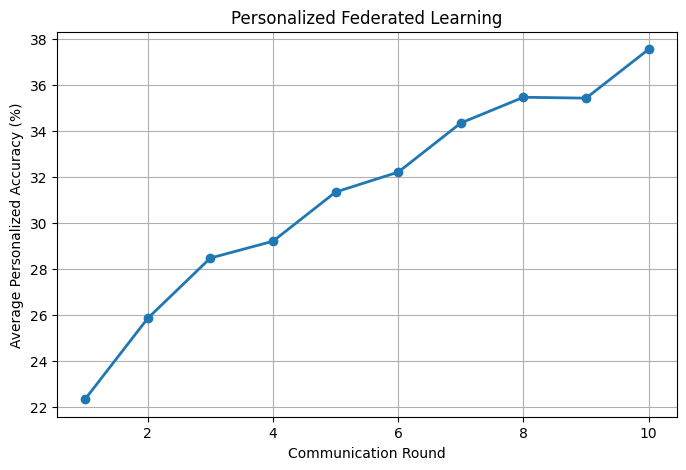

In [14]:
# ============================================================
# PERSONALIZED ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,ROUNDS+1),
    global_accuracy,
    marker="o",
    linewidth=2
)

plt.xlabel("Communication Round")
plt.ylabel("Average Personalized Accuracy (%)")
plt.title("Personalized Federated Learning")

plt.grid(True)

plt.show()

In [15]:
# ============================================================
# SAVE PERSONALIZED MODELS
# ============================================================

SAVE_DIR = "saved_models"

os.makedirs(SAVE_DIR, exist_ok=True)

for client in personalized_models:

    torch.save(

        personalized_models[client].state_dict(),

        os.path.join(
            SAVE_DIR,
            f"client_{client}.pth"
        )
    )

print("="*60)
print("Saved",len(personalized_models),"Personalized Models")
print("="*60)

Saved 10 Personalized Models


In [16]:
# ============================================================
# SAVE METRICS
# ============================================================

RESULT_DIR = "results"

os.makedirs(RESULT_DIR, exist_ok=True)

metrics = pd.DataFrame({

    "Round":range(1,ROUNDS+1),

    "Average Personalized Accuracy":global_accuracy

})

metrics.to_csv(

    os.path.join(
        RESULT_DIR,
        "personalized_fl_metrics.csv"
    ),

    index=False

)

print(metrics)

   Round  Average Personalized Accuracy
0      1                         22.354
1      2                         25.869
2      3                         28.491
3      4                         29.222
4      5                         31.360
5      6                         32.227
6      7                         34.363
7      8                         35.482
8      9                         35.443
9     10                         37.570


In [17]:
# ============================================================
# SUMMARY
# ============================================================

print("="*60)
print("PERSONALIZED FEDERATED LEARNING COMPLETED")
print("="*60)

print(f"Clients                 : {NUM_CLIENTS}")
print(f"Communication Rounds    : {ROUNDS}")
print(f"Local Epochs            : {LOCAL_EPOCHS}")
print(f"Personalization Epochs  : {PERSONAL_EPOCHS}")

print()

print(f"Final Personalized Accuracy : {global_accuracy[-1]:.2f}%")

print("="*60)

PERSONALIZED FEDERATED LEARNING COMPLETED
Clients                 : 10
Communication Rounds    : 10
Local Epochs            : 1
Personalization Epochs  : 1

Final Personalized Accuracy : 37.57%
